In [1]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\HDC0422136\EXP-3
['.ipynb_checkpoints', 'EXP3_EDA_Data_Cleaning.ipynb', 'Titanic-Dataset.csv']


In [2]:
import pandas as pd

df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")

In [5]:
print("INITIAL DATA OVERVIEW")
print("-"*50)

print("\nFirst 5 Rows")
print(df.head())

print("\nShape of Dataset")
print(df.shape)

print("\nColumn Names")
print(df.columns)

INITIAL DATA OVERVIEW
--------------------------------------------------

First 5 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            1

In [6]:
print("DATASET INFORMATION")
print("-"*50)

df.info()

DATASET INFORMATION
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print("STATISTICAL SUMMARY")
print("-"*50)

print(df.describe())

STATISTICAL SUMMARY
--------------------------------------------------
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


In [8]:
print("="*60)
print("MISSING VALUES IN EACH COLUMN")
print("="*60)

print(df.isnull().sum())

MISSING VALUES IN EACH COLUMN
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


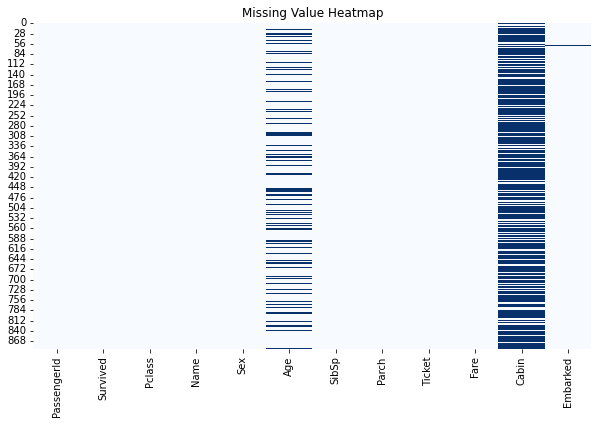

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df.isnull(),
            cbar=False,
            cmap="Blues")

plt.title("Missing Value Heatmap")

plt.show()

In [10]:
print("="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Fill Age with Median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Embarked with Mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Fill Cabin with "Unknown"
df["Cabin"] = df["Cabin"].fillna("Unknown")

print("Missing values handled successfully.")

HANDLING MISSING VALUES
Missing values handled successfully.


In [11]:
print("="*60)
print("MISSING VALUES AFTER CLEANING")
print("="*60)

print(df.isnull().sum())

MISSING VALUES AFTER CLEANING
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


In [12]:
print("="*60)
print("REMOVING DUPLICATE RECORDS")
print("="*60)

initial_rows = df.shape[0]

print("Duplicate Rows Before Removing :", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("Duplicate Rows After Removing  :", df.duplicated().sum())

print("Current Dataset Shape :", df.shape)

REMOVING DUPLICATE RECORDS
Duplicate Rows Before Removing : 0
Duplicate Rows After Removing  : 0
Current Dataset Shape : (891, 12)


In [13]:
print("="*60)
print("DATA TYPE CONVERSION")
print("="*60)

# Convert Age to integer
df["Age"] = df["Age"].astype(int)

print(df.dtypes)

DATA TYPE CONVERSION
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age              int32
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [14]:
print("="*60)
print("DATA CONSISTENCY")
print("="*60)

# Standardize text columns
df["Sex"] = df["Sex"].str.strip().str.capitalize()
df["Embarked"] = df["Embarked"].str.strip().str.upper()

print(df[["Sex", "Embarked"]].head())

DATA CONSISTENCY
      Sex Embarked
0    Male        S
1  Female        C
2  Female        S
3  Female        S
4    Male        S


In [15]:
print("="*60)
print("NORMALIZATION")
print("="*60)

scaler = MinMaxScaler()

columns = ["Age", "Fare"]

df[columns] = scaler.fit_transform(df[columns])

print("Age and Fare normalized successfully.")

NORMALIZATION
Age and Fare normalized successfully.


In [16]:
print("="*60)
print("CLEANED DATASET")
print("="*60)

print("\nFirst 10 Rows")
print(df.head(10))

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nMissing Values")
print(df.isnull().sum())

CLEANED DATASET

First 10 Rows
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex     Age  SibSp  \
0                            Braund, Mr. Owen Harris    Male  0.2750      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  Female  0.4750      1   
2                             Heikkinen, Miss. Laina  Female  0.3250      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  Female  0.4375      1   
4                           Allen, Mr. William Henry    Male  0.4375      0   
5                                   Moran, Mr. James    Male  0.3500      0   
6                  

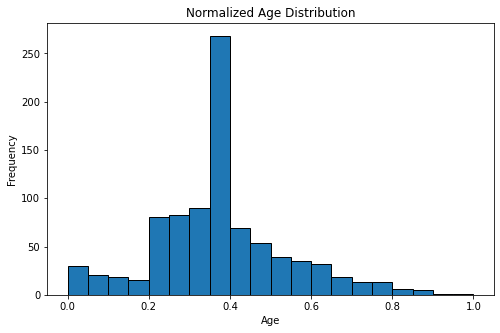

In [17]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=20, edgecolor="black")

plt.title("Normalized Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

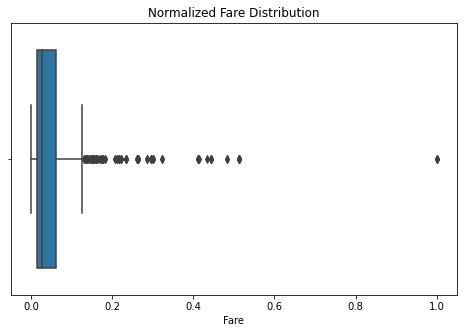

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Normalized Fare Distribution")

plt.show()

In [19]:
print("="*60)
print("RESULT")
print("="*60)

print("The Titanic dataset was cleaned successfully.")
print("✓ Missing values handled")
print("✓ Duplicate records removed")
print("✓ Data types converted")
print("✓ Text values standardized")
print("✓ Numerical columns normalized")
print("✓ Clean dataset ready for analysis")

RESULT
The Titanic dataset was cleaned successfully.
✓ Missing values handled
✓ Duplicate records removed
✓ Data types converted
✓ Text values standardized
✓ Numerical columns normalized
✓ Clean dataset ready for analysis
